In [1]:
import numpy as np
import pandas as pd

# --- Parameters ---
n_total          = 10_000  # total annotations
small_group_frac = 0.10    # fraction of annotations from the smaller group (group 2)
group_rates      = {1: 0.60, 2: 0.45}  # true rating rate per group
llm_error_base   = 0.10    # LLM error rate for the larger group (group 1)
llm_error_extra  = 0.20    # additional LLM error for the smaller group (group 2)
human_frac       = 0.20    # fraction of samples with human annotations
burnin_size      = 100     # first N human-annotated samples (collected uniformly)

random_state = 42
# ------------------

rng = np.random.default_rng(random_state)

n_small = int(n_total * small_group_frac)
n_large = n_total - n_small
llm_error_rates = {1: llm_error_base, 2: llm_error_base + llm_error_extra}
group_ns = {1: n_large, 2: n_small}

records = []
for group, n in group_ns.items():
    human = rng.binomial(1, group_rates[group],     size=n)
    flips = rng.binomial(1, llm_error_rates[group], size=n)
    llm   = (human != flips).astype(int)
    for i, (h, l) in enumerate(zip(human, llm)):
        records.append({'sample_id': i, 'group': group,
                        'human_rating': h, 'llm_rating': l})

# shuffle so groups are interleaved (realistic)
df = pd.DataFrame(records).sample(frac=1, random_state=random_state).reset_index(drop=True)

print(f"Total annotations : {len(df)}")
print(f"{'Group':<8} {'N':>6} {'Frac':>6} {'Human rate':>12} {'LLM error':>10} {'Target error':>13}")
print('-' * 60)
for g in [1, 2]:
    mask = df['group'] == g
    n_g  = mask.sum()
    err  = (df.loc[mask, 'human_rating'] != df.loc[mask, 'llm_rating']).mean()
    print(f"{g:<8} {n_g:>6} {n_g/n_total:>6.2f} "
          f"{df.loc[mask,'human_rating'].mean():>12.3f} "
          f"{err:>10.3f} {llm_error_rates[g]:>13.2f}")

df.head(6)


Total annotations : 10000
Group         N   Frac   Human rate  LLM error  Target error
------------------------------------------------------------
1          9000   0.90        0.606      0.101          0.10
2          1000   0.10        0.445      0.314          0.30


,sample_id,group,human_rating,llm_rating
0,6252,1,1,1
1,4684,1,0,0
2,1731,1,1,1
3,4742,1,0,0
4,4521,1,1,1
5,6340,1,0,0


In [2]:
from scipy.stats import norm as scipy_norm
from tqdm.notebook import tqdm
from utils.inference import train_sampling_rule, sampling_rule_predict, perspective_driven_inference
from ppi_py import ppi_mean_pointestimate, ppi_mean_ci

# --- Trial parameters ---
n_trials  = 20
n_batches = 3
alpha     = 0.05
tau       = 0.1
q_power   = 1.0
# ------------------------

N        = len(df)
n_human  = max(int(N * human_frac), burnin_size)
z_crit   = scipy_norm.ppf(1 - alpha / 2)

H_true   = df['human_rating'].values.astype(float)
Hhat     = df['llm_rating'].values.astype(float)
features = (df['group'] == 2).astype(float).values.reshape(-1, 1)

groups_list = [1, 2]
group_masks = [df['group'].values == g for g in groups_list]
true_thetas = np.array([group_rates[g] for g in groups_list])

def mean_estimator(y, weights):
    mask = ~np.isnan(y)
    return np.sum(y[mask] * weights[mask]) / np.sum(weights[mask])

methods = ['LLM', 'PPI', 'PDI']
ests    = {m: np.full((n_trials, len(groups_list)), np.nan) for m in methods}
covered = {m: np.full((n_trials, len(groups_list)), np.nan) for m in methods}

batch_size = (N - burnin_size) // n_batches

for trial in tqdm(range(n_trials), desc='Trials'):
    np.random.seed(random_state + trial * 13)

    ppi_idx = np.random.choice(N, size=n_human, replace=False)
    ppi_sel = np.zeros(N, dtype=bool)
    ppi_sel[ppi_idx] = True

    H  = np.full(N, np.nan)
    SP = np.zeros(N)
    SD = np.zeros(N)

    H[:burnin_size]  = H_true[:burnin_size]
    SP[:burnin_size] = 1.0
    SD[:burnin_size] = 1.0

    sampling_rule = train_sampling_rule(
        features[:burnin_size],
        (H[:burnin_size] - Hhat[:burnin_size]) ** 2,
        seed=random_state)
    q = np.clip(sampling_rule_predict(sampling_rule, features), 1e-8, None) ** q_power

    for b in range(n_batches):
        start = burnin_size + b * batch_size
        end   = burnin_size + (b + 1) * batch_size if b < n_batches - 1 else N
        batch = np.arange(start, end)

        remaining = n_human - int(SD.sum())
        if remaining <= 0:
            break
        target = min(round(remaining / (n_batches - b)), remaining, len(batch))

        p = q[batch];  p = p / p.sum()
        p = (1 - tau) * p + tau / len(batch);  p = p / p.sum()

        sel = np.random.choice(len(batch), size=target, replace=False, p=p)
        H[batch[sel]]  = H_true[batch[sel]]
        SD[batch]      = 0.0;  SD[batch[sel]] = 1.0
        SP[batch]      = np.clip(target * p, 1e-4, 1.0)

        if b < n_batches - 1:
            obs = np.where(~np.isnan(H))[0]
            sampling_rule = train_sampling_rule(
                features[obs], (H[obs] - Hhat[obs]) ** 2, seed=random_state)
            q = np.clip(sampling_rule_predict(sampling_rule, features), 1e-8, None) ** q_power

    for g_idx, (mask, true_theta) in enumerate(zip(group_masks, true_thetas)):
        lm = Hhat[mask & ppi_sel]
        if len(lm) >= 2:
            est = lm.mean()
            se  = np.sqrt(max(est * (1 - est), 1e-6) / len(lm))
            ests['LLM'][trial, g_idx]    = est
            covered['LLM'][trial, g_idx] = int(est - z_crit*se <= true_theta <= est + z_crit*se)

        g_lab   = mask & ppi_sel
        g_unlab = mask & ~ppi_sel
        if g_lab.sum() >= 2 and g_unlab.sum() >= 1:
            est    = ppi_mean_pointestimate(H_true[g_lab], Hhat[g_lab], Hhat[g_unlab], lam=None)
            lb, ub = ppi_mean_ci(H_true[g_lab], Hhat[g_lab], Hhat[g_unlab], alpha=alpha, lam=None)
            ests['PPI'][trial, g_idx]    = est
            covered['PPI'][trial, g_idx] = int(lb <= true_theta <= ub)

        if SD[mask].sum() >= 2:
            est, (lb, ub), _ = perspective_driven_inference(
                mean_estimator,
                Y=H[mask], Yhat=Hhat[mask],
                sampling_probs=SP[mask], sampling_decisions=SD[mask],
                alpha=alpha, lam=None, n_resamples=100, n_resamples_lam=20)
            ests['PDI'][trial, g_idx]    = est
            covered['PDI'][trial, g_idx] = int(lb <= true_theta <= ub)

print("Trials complete.")


Trials:   0%|          | 0/20 [00:00<?, ?it/s]

Trials complete.


In [3]:
ci_level = int((1 - alpha) * 100)
mw = 8
sep = '=' * 40
sub = '-' * 40

print(f"Coverage & Avg Delta  (target {ci_level}%,  n_human={n_human},  {n_trials} trials,  N={N})")
print(f"Avg Delta = mean |estimate - true theta| in percentage points  (lower = better)")

for g_idx, g in enumerate(groups_list):
    true_theta = true_thetas[g_idx]
    n_g = group_masks[g_idx].sum()
    print(f"\nGroup {g}  (N={n_g}, true rate={true_theta:.2f}, LLM error={llm_error_rates[g]:.2f})")
    print(sep)
    print(f"{'Method':<{mw}} {'Coverage':>10} {'Avg Delta (%pt)':>16}")
    print(sub)
    for m in methods:
        cov   = np.nanmean(covered[m][:, g_idx])
        delta = np.nanmean(np.abs(ests[m][:, g_idx] - true_theta)) * 100
        print(f"{m:<{mw}} {cov:>10.3f} {delta:>16.2f}")
    print(sep)


Coverage & Avg Delta  (target 95%,  n_human=2000,  20 trials,  N=10000)
Avg Delta = mean |estimate - true theta| in percentage points  (lower = better)

Group 1  (N=9000, true rate=0.60, LLM error=0.10)
Method     Coverage  Avg Delta (%pt)
----------------------------------------
LLM           0.650             2.17
PPI           0.950             0.70
PDI           0.950             1.06

Group 2  (N=1000, true rate=0.45, LLM error=0.30)
Method     Coverage  Avg Delta (%pt)
----------------------------------------
LLM           0.900             2.28
PPI           1.000             2.30
PDI           1.000             1.19


In [4]:
import matplotlib.pyplot as plt

def run_trials_for_params(p):
    """Generate synthetic data and run LLM / PPI / PDI trials for given params dict."""
    rng = np.random.default_rng(p['random_state'])

    n_small  = int(p['n_total'] * p['small_group_frac'])
    n_large  = p['n_total'] - n_small
    llm_err  = {1: p['llm_error_base'], 2: p['llm_error_base'] + p['llm_error_extra']}
    group_ns = {1: n_large, 2: n_small}

    records = []
    for group, n in group_ns.items():
        human = rng.binomial(1, p['group_rates'][group], size=n)
        flips = rng.binomial(1, llm_err[group], size=n)
        llm   = (human != flips).astype(int)
        for h, l in zip(human, llm):
            records.append({'group': group, 'human_rating': h, 'llm_rating': l})

    df_loc = pd.DataFrame(records).sample(frac=1, random_state=p['random_state']).reset_index(drop=True)

    N_loc      = len(df_loc)
    burnin     = min(p['burnin_size'], int(N_loc * p['human_frac']) - 1)  # guard: burnin < n_human
    n_human_loc= max(int(N_loc * p['human_frac']), burnin + 1)
    H_true_loc = df_loc['human_rating'].values.astype(float)
    Hhat_loc   = df_loc['llm_rating'].values.astype(float)
    feats_loc  = (df_loc['group'] == 2).astype(float).values.reshape(-1, 1)
    masks_loc  = [df_loc['group'].values == g for g in [1, 2]]
    thetas_loc = np.array([p['group_rates'][g] for g in [1, 2]])
    z_crit_loc = scipy_norm.ppf(1 - p['alpha'] / 2)
    bs_loc     = (N_loc - burnin) // p['n_batches']

    methods = ['LLM', 'PPI', 'PDI']
    ests    = {m: np.full((p['n_trials'], 2), np.nan) for m in methods}
    covered = {m: np.full((p['n_trials'], 2), np.nan) for m in methods}

    for trial in range(p['n_trials']):
        np.random.seed(p['random_state'] + trial * 13)

        ppi_idx = np.random.choice(N_loc, size=n_human_loc, replace=False)
        ppi_sel = np.zeros(N_loc, dtype=bool)
        ppi_sel[ppi_idx] = True

        H  = np.full(N_loc, np.nan)
        SP = np.zeros(N_loc)
        SD = np.zeros(N_loc)
        H[:burnin]  = H_true_loc[:burnin]
        SP[:burnin] = 1.0
        SD[:burnin] = 1.0

        srule = train_sampling_rule(feats_loc[:burnin], (H[:burnin] - Hhat_loc[:burnin])**2, seed=p['random_state'])
        q = np.clip(sampling_rule_predict(srule, feats_loc), 1e-8, None) ** p['q_power']

        for b in range(p['n_batches']):
            start = burnin + b * bs_loc
            end   = burnin + (b+1) * bs_loc if b < p['n_batches']-1 else N_loc
            batch = np.arange(start, end)
            remaining = n_human_loc - int(SD.sum())
            if remaining <= 0 or len(batch) == 0:
                break
            target = min(round(remaining / (p['n_batches'] - b)), remaining, len(batch))
            prob = q[batch]; prob = prob / prob.sum()
            prob = (1 - p['tau']) * prob + p['tau'] / len(batch); prob = prob / prob.sum()
            sel  = np.random.choice(len(batch), size=target, replace=False, p=prob)
            H[batch[sel]]  = H_true_loc[batch[sel]]
            SD[batch]      = 0.0; SD[batch[sel]] = 1.0
            SP[batch]      = np.clip(target * prob, 1e-4, 1.0)
            if b < p['n_batches']-1:
                obs   = np.where(~np.isnan(H))[0]
                srule = train_sampling_rule(feats_loc[obs], (H[obs] - Hhat_loc[obs])**2, seed=p['random_state'])
                q     = np.clip(sampling_rule_predict(srule, feats_loc), 1e-8, None) ** p['q_power']

        for g_idx, (mask, tt) in enumerate(zip(masks_loc, thetas_loc)):
            lm = Hhat_loc[mask & ppi_sel]
            if len(lm) >= 2:
                est = lm.mean()
                se  = np.sqrt(max(est*(1-est), 1e-6) / len(lm))
                ests['LLM'][trial, g_idx]    = est
                covered['LLM'][trial, g_idx] = int(est - z_crit_loc*se <= tt <= est + z_crit_loc*se)
            g_lab, g_unlab = mask & ppi_sel, mask & ~ppi_sel
            if g_lab.sum() >= 2 and g_unlab.sum() >= 1:
                est    = ppi_mean_pointestimate(H_true_loc[g_lab], Hhat_loc[g_lab], Hhat_loc[g_unlab], lam=None)
                lb, ub = ppi_mean_ci(H_true_loc[g_lab], Hhat_loc[g_lab], Hhat_loc[g_unlab], alpha=p['alpha'], lam=None)
                ests['PPI'][trial, g_idx]    = est
                covered['PPI'][trial, g_idx] = int(lb <= tt <= ub)
            if SD[mask].sum() >= 2:
                est, (lb, ub), _ = perspective_driven_inference(
                    mean_estimator, Y=H[mask], Yhat=Hhat_loc[mask],
                    sampling_probs=SP[mask], sampling_decisions=SD[mask],
                    alpha=p['alpha'], lam=None, n_resamples=100, n_resamples_lam=20)
                ests['PDI'][trial, g_idx]    = est
                covered['PDI'][trial, g_idx] = int(lb <= tt <= ub)

    return ests, covered, thetas_loc


In [5]:
defaults = dict(
    n_total          = 10_000,
    small_group_frac = 0.10,
    group_rates      = {1: 0.60, 2: 0.45},
    llm_error_base   = 0.10,
    llm_error_extra  = 0.20,
    human_frac       = 0.20,
    burnin_size      = 100,
    n_trials         = 10,
    n_batches        = 3,
    alpha            = 0.05,
    tau              = 0.1,
    q_power          = 1.0,
    random_state     = 42,
)

experiments = [
    dict(
        name   = '1. Human annotation budget',
        param  = 'human_frac',
        values = [0.05, 0.10, 0.15, 0.20, 0.30, 0.40],
        xlabel = 'Human budget (% of N)',
        xfmt   = lambda v: f'{int(v*100)}%',
    ),
    dict(
        name   = '2. Burn-in size',
        param  = 'burnin_size',
        values = [25, 50, 100, 200, 400],
        xlabel = 'Burn-in size (# samples)',
        xfmt   = lambda v: str(v),
    ),
    dict(
        name   = '3. LLM extra error on smaller group',
        param  = 'llm_error_extra',
        values = [0.0, 0.10, 0.20, 0.30, 0.40, 0.50],
        xlabel = 'Extra LLM error on group 2',
        xfmt   = lambda v: f'+{int(v*100)}%',
    ),
    dict(
        name   = '4. Size of smaller group',
        param  = 'small_group_frac',
        values = [0.05, 0.10, 0.20, 0.30, 0.50],
        xlabel = 'Smaller group fraction',
        xfmt   = lambda v: f'{int(v*100)}%',
    ),
]

methods      = ['LLM', 'PPI', 'PDI']
group_labels = {0: 'group 1 (larger)', 1: 'group 2 (smaller)'}

# experiment_results[exp_name][g_idx][method] = {'cov', 'cov_se', 'delta', 'delta_se'}
experiment_results = {}

for exp in tqdm(experiments, desc='Experiments'):
    param  = exp['param']
    values = exp['values']
    res    = {g: {m: {'cov': [], 'cov_se': [], 'delta': [], 'delta_se': []}
                  for m in methods}
              for g in [0, 1]}

    for v in tqdm(values, desc=param, leave=False):
        p = {**defaults, param: v}
        ests_v, cov_v, thetas_v = run_trials_for_params(p)
        for g in [0, 1]:
            for m in methods:
                cov_trials   = cov_v[m][:, g]
                delta_trials = np.abs(ests_v[m][:, g] - thetas_v[g]) * 100
                n_t = np.sum(~np.isnan(cov_trials))
                res[g][m]['cov'].append(np.nanmean(cov_trials))
                res[g][m]['cov_se'].append(np.nanstd(cov_trials) / np.sqrt(n_t))
                res[g][m]['delta'].append(np.nanmean(delta_trials))
                res[g][m]['delta_se'].append(np.nanstd(delta_trials) / np.sqrt(n_t))

    experiment_results[exp['name']] = {'res': res, 'values': values, 'exp': exp}

print("All experiments done.")


Experiments:   0%|          | 0/4 [00:00<?, ?it/s]

human_frac:   0%|          | 0/6 [00:00<?, ?it/s]

burnin_size:   0%|          | 0/5 [00:00<?, ?it/s]

llm_error_extra:   0%|          | 0/6 [00:00<?, ?it/s]

small_group_frac:   0%|          | 0/5 [00:00<?, ?it/s]

All experiments done.


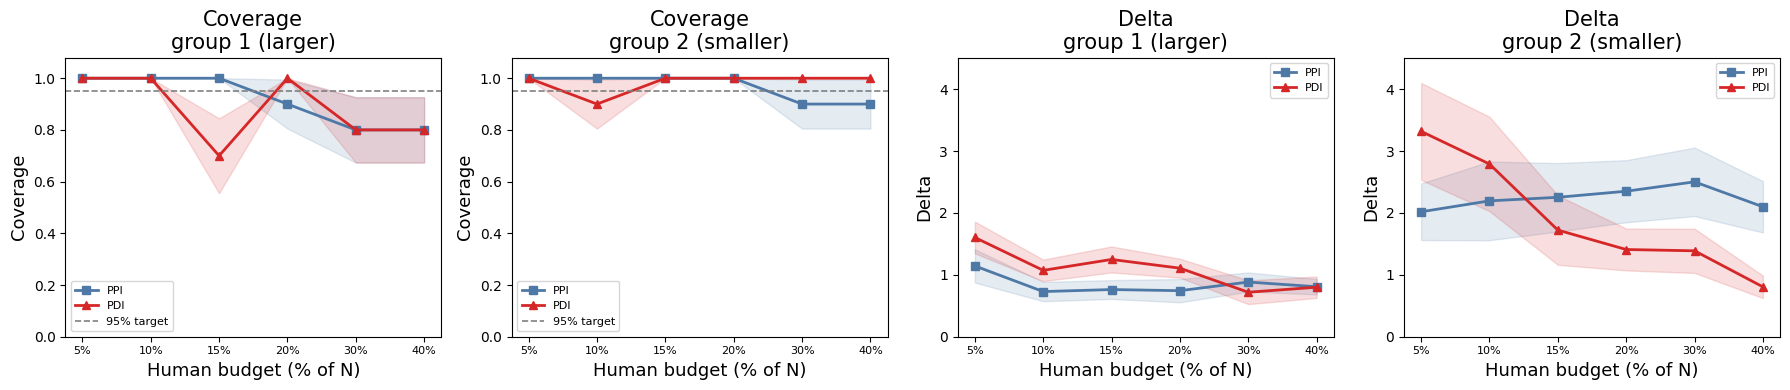

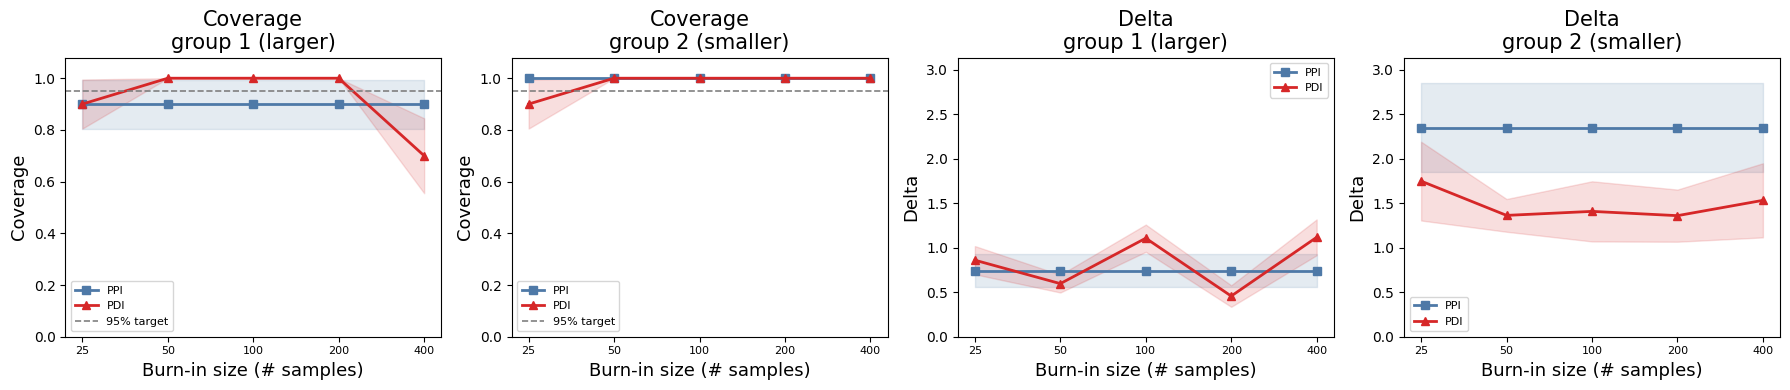

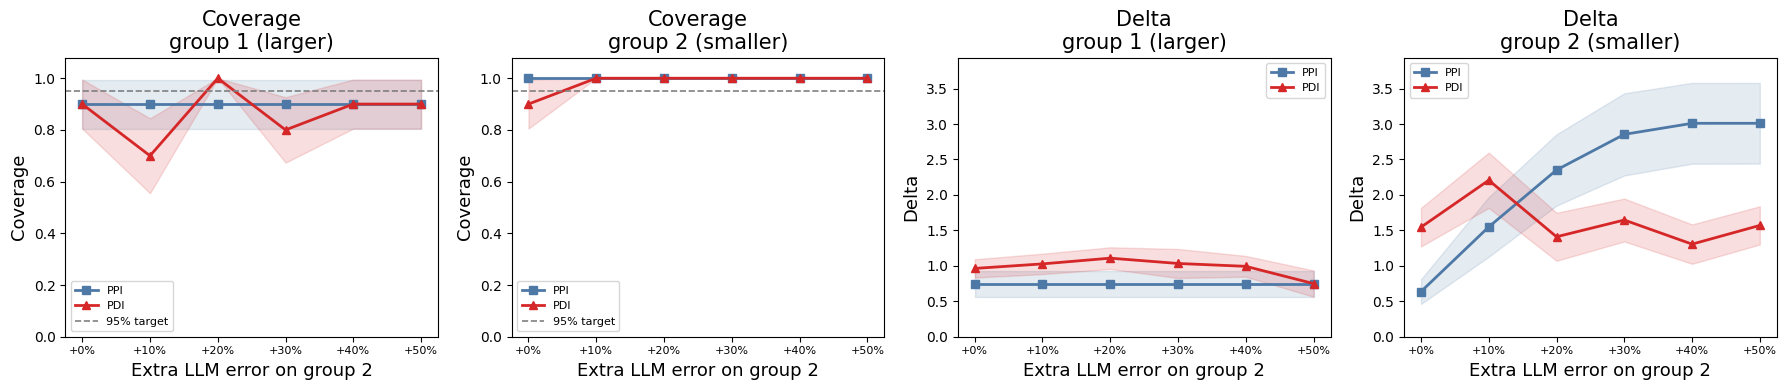

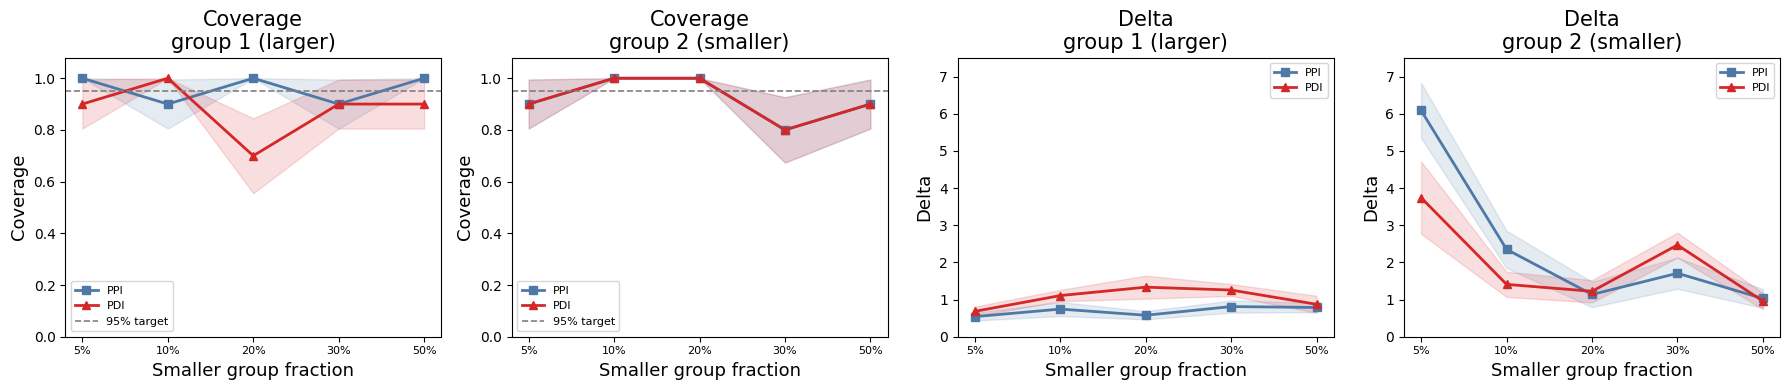

In [23]:
colors  = {'LLM': '#e15759', 'PPI': '#4e79a7', 'PDI': 'tab:red'}
markers = {'LLM': 'o',       'PPI': 's',       'PDI': '^'}


for exp_name, data in experiment_results.items():
    res     = data['res']
    values  = data['values']
    exp     = data['exp']
    x       = np.arange(len(values))
    xlabels = [exp['xfmt'](v) for v in values]

    # compute shared y limits for delta across both groups
    all_delta_vals = [
        np.array(res[g][m]['delta']) + np.array(res[g][m]['delta_se'])
        for g in [0, 1] for m in ['PPI','PDI']
    ]
    delta_ymin = 0
    delta_ymax = np.max([v.max() for v in all_delta_vals]) * 1.1

    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    #fig.suptitle(f'Experiment {exp_name}', fontsize=12)

    panel_specs = [
        (axes[0], 0, 'cov',   'Coverage',  'Coverage',                  True),
        (axes[1], 1, 'cov',   'Coverage',  'Coverage',                  True),
        (axes[2], 0, 'delta', 'Delta', 'Delta', False),
        (axes[3], 1, 'delta', 'Delta', 'Delta', False),
    ]

    for ax, g, metric, title, ylabel, add_target in panel_specs:
        gl = group_labels[g]
        for m in ['PPI','PDI']:
            vals = np.array(res[g][m][metric])
            se   = np.array(res[g][m][f'{metric}_se'])
            ax.plot(x, vals, color=colors[m], marker=markers[m], label=m, linewidth=2)
            ax.fill_between(x, vals - se, vals + se, color=colors[m], alpha=0.15)
        if add_target:
            ax.axhline(1 - defaults['alpha'], color='gray', linestyle='--',
                       linewidth=1.2, label='95% target')
            ax.set_ylim(0, 1.08)
        if metric == 'delta':
            ax.set_ylim(delta_ymin, delta_ymax)
        ax.set_title(f'{title}\n{gl}', fontsize=15)
        ax.set_ylabel(ylabel, fontsize = 13)
        ax.set_xticks(x);  ax.set_xticklabels(xlabels, fontsize=8)
        ax.set_xlabel(exp['xlabel'], fontsize=13)
        ax.legend(fontsize=8)

    plt.tight_layout()
    fig.savefig(f"synthetic_{exp_name}.pdf", bbox_inches="tight")
    plt.show()


